# Getting Started with scikit-learn (Diabetes Regression)

scikit-learn (or sklearn) is a popular Python library that provides simple and efficient tools for data mining and machine learning. It offers easy-to-use implementations of many supervised and unsupervised algorithms, plus utilities for data preprocessing, model evaluation, and pipeline building.

## Core Concepts in scikit-learn
- **Estimator**: Any object that learns from data (e.g., classifier, regressor, transformer)
- **Fit**: Train the model on data
- **Predict**: Make predictions on new data
- **Transform**: Modify or extract features from data (e.g., scaling, PCA)
- **Pipeline**: Chain multiple steps (preprocessing + model) into one object

## What is Regression?
Regression is a type of supervised machine learning used to predict continuous numerical values. Unlike classification (which predicts categories), regression is useful when the target variable is a number—such as house prices, temperature, or age.

> **Example use case**: Predicting the price of a house based on its size.

## Linear Regression Overview
Linear Regression models the relationship between one (or more) input features (independent variables) and a numeric target variable (dependent variable) by fitting a straight line to the data.

The general form of the linear equation is:  
$y = mx + b$

- $y$: Predicted value (e.g., house price)
- $x$: Input feature (e.g., house size)
- $m$: Slope (coefficient)
- $b$: Intercept (value when $x = 0$)

The model learns the values of $m$ and $b$ that best fit the training data using a method called **least squares**.

**Ordinary least squares Linear Regression**: `LinearRegression` fits a linear model with coefficients $w = (w_1, \dots, w_p)$ to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation.

## Prerequisites

Install the required libraries if you haven't already:

```bash
pip install scikit-learn numpy pandas matplotlib
```

We'll use:
- **scikit-learn**: ML models, data loading, evaluation
- **numpy**: Numerical operations
- **pandas**: Data exploration
- **matplotlib**: Visualization

## Step 1: Import Required Libraries

In [3]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn tools
from sklearn.datasets import load_diabetes  # Load dataset
from sklearn.model_selection import train_test_split  # Split data
from sklearn.linear_model import LinearRegression  # Regression model
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics

## Step 2: Load and Explore the Diabetes Dataset

The `load_diabetes()` dataset is a classic regression dataset for predicting diabetes progression based on 10 clinical features (age, BMI, blood pressure, etc.).

The dataset is a dictionary-like object with 4 key components:
- `data`: Feature values (predictors)
- `target`: Target value (continuous diabetes progression score)
- `feature_names`: Names of the 10 features
- `DESCR`: Full dataset description

In [4]:
# Load the dataset
diabetes = load_diabetes()

# Print dataset description
print(diabetes.DESCR)

# Print feature names
print("\nFeature Names:", diabetes.feature_names)

# Check shape of data (samples, features)
print("\nData Shape:", diabetes.data.shape)  # (442 samples, 10 features)
print("Target Shape:", diabetes.target.shape)  # (442 target values)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
# Create DataFrame for features, if not pass columns it by default it will be 0,1,2...9
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
# Add target column to the DataFrame
df['disease_progression'] = diabetes.target

# Show first 5 rows
print("\nFirst 5 Rows of the Dataset:")
print(df.head())

# Basic statistics
print("\nDataset Statistics:")
print(df.describe())


First 5 Rows of the Dataset:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  disease_progression  
0 -0.002592  0.019907 -0.017646                151.0  
1 -0.039493 -0.068332 -0.092204                 75.0  
2 -0.002592  0.002861 -0.025930                141.0  
3  0.034309  0.022688 -0.009362                206.0  
4 -0.002592 -0.031988 -0.046641                135.0  

Dataset Statistics:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.5

**Key Notes:**
- All features are pre-normalized (mean=0, std=1) — scikit-learn does this for convenience.
- The target is a continuous integer (25–346) representing diabetes disease progression.

## Step 3: Prepare Data for Modeling

ML models require splitting data into features (X) and target (y), then into training and test sets.

In [6]:
# X = all features (predictors)
X = diabetes.data
# y = target value (diabetes progression score we want to predict)
y = diabetes.target

# Split data: 80% train, 20% test
# random_state=42 ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check split sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 353
Test samples: 89


## Step 4: Train a Regression Model

We'll use **Linear Regression**—the simplest and most interpretable regression algorithm (perfect for beginners).

In [7]:
# Create linear regression model
model = LinearRegression()

# Train the model on the TRAINING data
model.fit(X_train, y_train)

# Print feature coefficients
print("\nModel Coefficients (Feature Importance):")
for feature, coef in zip(diabetes.feature_names, model.coef_):
    print(f"{feature}: {coef:.2f}")

# Print intercept (base value when all features = 0)
print(f"\nIntercept: {model.intercept_:.2f}")


Model Coefficients (Feature Importance):
age: 37.90
sex: -241.96
bmi: 542.43
bp: 347.70
s1: -931.49
s2: 518.06
s3: 163.42
s4: 275.32
s5: 736.20
s6: 48.67

Intercept: 151.35


## Step 5: Make Predictions

Use the trained model to predict diabetes progression for the test set (data the model has never seen).

In [8]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare first 5 actual vs predicted values
print("\nFirst 5 Actual vs Predicted Diabetes Progression Scores:")
comparison = pd.DataFrame({
    'Actual': y_test[:5],
    'Predicted': y_pred[:5]
})
print(comparison)


First 5 Actual vs Predicted Diabetes Progression Scores:
   Actual   Predicted
0   219.0  139.547558
1    70.0  179.517208
2   202.0  134.038756
3   230.0  291.417029
4   111.0  123.789659


## Step 6: Evaluate Model Performance

We use two standard regression metrics to measure accuracy:
- **Mean Squared Error (MSE)**: Lower = better (average squared difference between actual and predicted values)
- **R² Score**: 0–1 (higher = better; 1 = perfect prediction)

In [9]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root MSE (easier to interpret)
r2 = r2_score(y_test, y_pred)

# Print results
print("\nModel Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Model Performance Metrics:
Mean Squared Error (MSE): 2900.19
Root Mean Squared Error (RMSE): 53.85
R² Score: 0.45


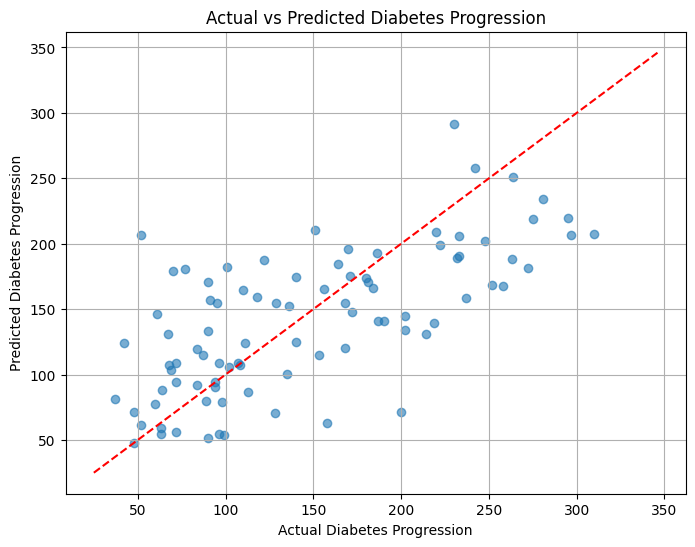

In [10]:
# Visualize Predictions vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Perfect prediction line
plt.xlabel('Actual Diabetes Progression')
plt.ylabel('Predicted Diabetes Progression')
plt.title('Actual vs Predicted Diabetes Progression')
plt.grid(True)
plt.show()

The red dashed line = perfect predictions.  
Points close to the line = accurate predictions.

## Step 7: (Optional) Predict on New Custom Data

Use your trained model to predict for a new patient!

In [11]:
# Example: Create a new patient's feature values (matches 10 normalized features)
new_patient = np.array([[0.01, 0.02, 0.03, 0.01, -0.01, -0.04, 0.05, -0.02, 0.03, 0.01]])

# Make prediction
predicted_score = model.predict(new_patient)
print(f"Predicted Diabetes Progression Score for New Patient: {predicted_score[0]:.2f}")

Predicted Diabetes Progression Score for New Patient: 180.46


## Full Working Code (Copy-Paste)

Model Performance:
RMSE: 53.85
R² Score: 0.45


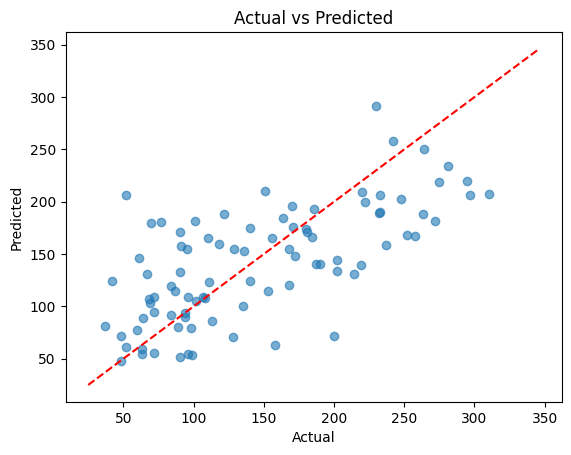

In [12]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot results
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

## Key Takeaways
- **scikit-learn workflow**: Load → Split → Train → Predict → Evaluate
- **Regression**: Predicts continuous values (e.g., diabetes progression)
- **Linear Regression**: Fast, interpretable baseline model for regression
- **Evaluation**: Use RMSE and R² to measure model accuracy
- **Train/test split**: Critical for testing model on unseen data

🚀 **Next steps**: Try more advanced models (e.g., `RandomForestRegressor`) to improve performance.